# Modelado Estocástico
## Estacionariedad e Invertibilidad



Para identificar si una proceso ARMA es estacionario, debemos analizar las raíces del polinomio de la parte AR, y para identificar si es invertible, debemos analizar las raíces del polinomio de la parte MA. En ambos casos el requerimiento es que las raíces estén afuera del círculo unitario.

A continuación desarrollamos este análisis:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)

Definimos los coeficientes de los componentes autorregresivos (AR) y de media móvil (MA), considerando el lag cero y el signo invertido de los componentes AR que requiere `statsmodel`. Luego generamos el proceso:

In [ ]:
np.random.seed(42)

arparams = np.array([.75, -.25])
maparams = np.array([.5])
ar = np.r_[1, -arparams]
ma = np.r_[1, maparams]

arma_process = ArmaProcess(ar, ma)

Al generar el proceso utilizando `statsmodel` podemos acceder a sus atributos para identificar si es estacionario (`isstationary`), invertible (`isivertible`) y las raíces de los polinomios AR (`arroots`) y MA (`maroots`).

In [ ]:
print(arma_process.isstationary)
print(arma_process.isinvertible)
raices_ar = arma_process.arroots
raices_ma = arma_process.maroots
print(f"Las raíces del polinomio AR son: {raices_ar}")
print(f"Las raíces del polinomio MA son: {raices_ma}")

True
True
Las raíces del polinomio AR son: [1.5-1.32287566j 1.5+1.32287566j]
Las raíces del polinomio MA son: [-2.]


Observamos las raíces obtenidas respecto al círculo unitario:

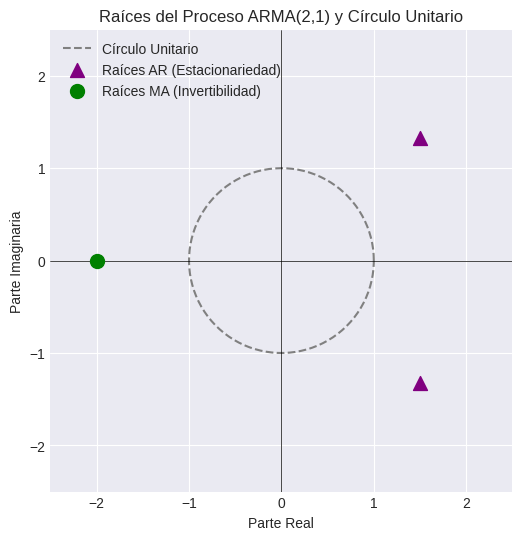

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))

angulo = np.linspace(0, 2 * np.pi, 200)
ax.plot(np.cos(angulo), np.sin(angulo), color='gray', linestyle='--', label='Círculo Unitario')

ax.scatter(np.real(raices_ar), np.imag(raices_ar), color='purple', marker='^', s=100, zorder=5, label='Raíces AR (Estacionariedad)')

ax.scatter(np.real(raices_ma), np.imag(raices_ma), color='green', marker='o', s=100, zorder=5, label='Raíces MA (Invertibilidad)')

ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-2.5, 2.5)
ax.set_xlabel('Parte Real')
ax.set_ylabel('Parte Imaginaria')
ax.set_title('Raíces del Proceso ARMA(2,1) y Círculo Unitario')
ax.legend(loc='upper left')
ax.set_aspect('equal')

plt.show()


Por otro lado, podemos ver los valores que toma la función impulso-respuesta de la siguiente manera (ver ejemplo II.5.2 de Carol Alexander):

In [ ]:
print(arma_process.impulse_response(10))


[ 1.          1.25        0.6875      0.203125   -0.01953125 -0.06542969
 -0.04418945 -0.01678467 -0.00154114  0.00304031]


Generemos ahora una serie sintética de 500 observaciones utilizando el proceso implementado previamente. Luego, tomamos la serie `y` generada y ajustamos el modelo utilizando `ARIMA` con los siguientes parámetros:
- `order=(2, 0, 1)` indica 2 rezagos autorregresivos (AR), 0 diferenciaciones (I) y 1 rezago de media móvil (MA).
- `trend = 'n'` significa "no trend" (sin tendencia ni constante).

`params` devuelve los coeficientes estimados por máxima verosimilitud. Dado que la muestra es finita, los parámetros no serán exactamente iguales a los definidos, pero serán una aproximación a $$\rho_1 = 0.75$$ $$\rho_2 = -0.25$$ $$\theta_1 = 0.5$$


In [ ]:
y = arma_process.generate_sample(500)
model = sm.tsa.ARIMA(y, order=(2, 0, 1), trend='n').fit()
print(model.params)

[ 0.72567538 -0.24122991  0.52624899  0.96019455]


Graficamos la serie generada:

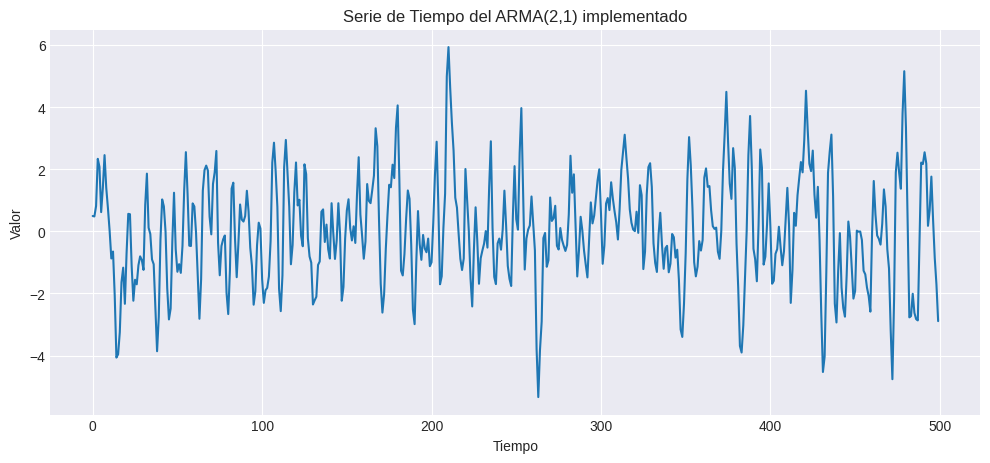

In [ ]:
plt.plot(y)
plt.title(r'Serie de Tiempo del ARMA(2,1) implementado')
plt.xlabel("Tiempo")
plt.ylabel("Valor")
plt.show()

Graficamos ACF y PACF

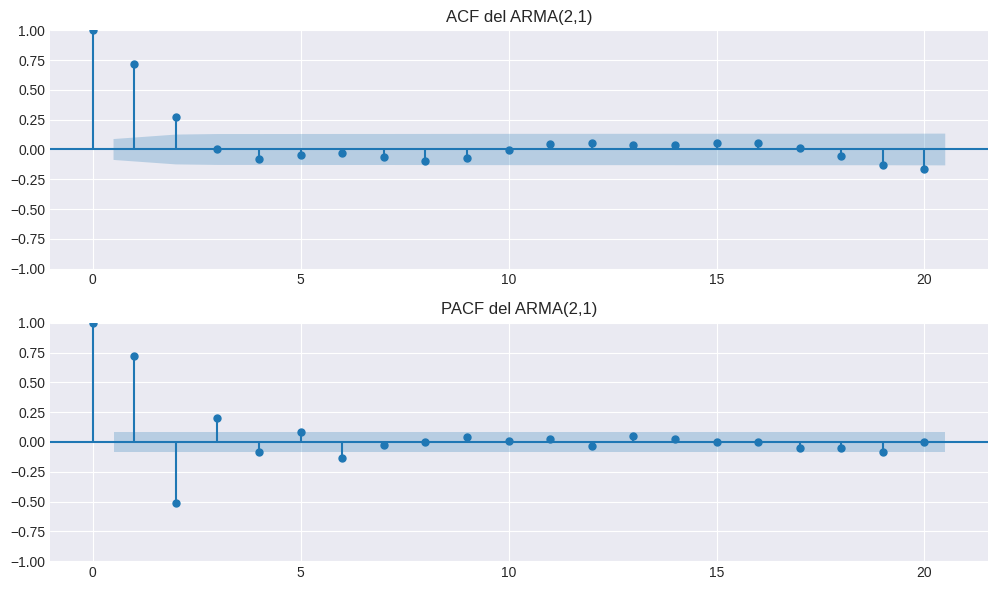

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6))

plot_acf(y, lags=20, ax=axes[0], title="ACF del ARMA(2,1)")

plot_pacf(y, lags=20, ax=axes[1], title="PACF del ARMA(2,1)")

plt.tight_layout()
plt.show()

Si queremos ver el resumen de la regresión que corrimos, en la obtuvimos los estimadores de los parámetros de la parte AR y MA:

In [ ]:
print(model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  500
Model:                 ARIMA(2, 0, 1)   Log Likelihood                -700.119
Date:                Sat, 15 Aug 2026   AIC                           1408.237
Time:                        12:54:43   BIC                           1425.096
Sample:                             0   HQIC                          1414.852
                                - 500                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7257      0.074      9.787      0.000       0.580       0.871
ar.L2         -0.2412      0.065     -3.706      0.000      -0.369      -0.114
ma.L1          0.5262      0.064      8.255      0.0